# Array Processing Project 1

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import utils

# Estimating Angles and Frequencies

### First generate data and analyze it

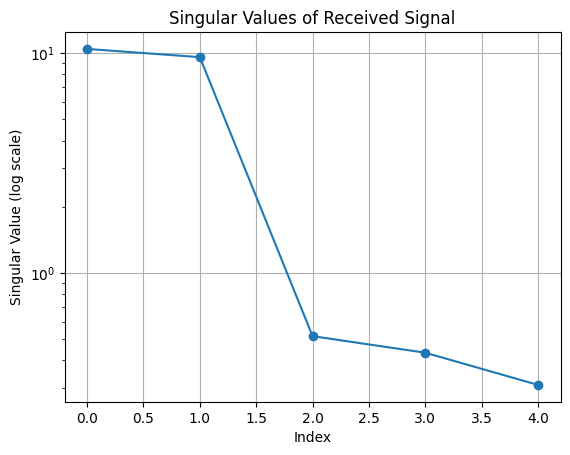

In [2]:
# Parameters
M = 5
N = 20
delta = 0.5
theta = [-20, 30]
f = [0.1, 0.3]
SNR = 20

# Generate data
X, A, S = utils.gendata(M, N, delta, theta, f, SNR)

# Plot singular values of the received signal
U, Sigma, Vh = np.linalg.svd(X)
plt.figure()
plt.semilogy(Sigma, 'o-')
plt.title('Singular Values of Received Signal')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.grid()
plt.show()

### Estimation of directions and frequencies using ESPIRT

In [3]:
# ESPRIT Algorithm for DOA Estimation
angles = utils.esprit(X, d=2)
print(f"Estimated DOA (degrees): {angles} at SNR = {SNR} dB")

# ESPRIT Algorithm for Frequency Estimation
frequencies = utils.espritfreq(X, d=2)
print(f"Estimated Frequencies: {frequencies} at SNR = {SNR} dB")

# Joint DOA and Frequency Estimation
angles_joint, frequencies_joint = utils.joint(X, d=2, m=M)
print(f"Joint Estimated DOA (degrees): {angles_joint} at SNR = {SNR} dB")
print(f"Joint Estimated Frequencies: {frequencies_joint} at SNR = {SNR} dB")

Estimated DOA (degrees): [-19.95975843  29.97324924] at SNR = 20 dB
Estimated Frequencies: [0.10026316 0.3004238 ] at SNR = 20 dB
Joint Estimated DOA (degrees): [-20.05985978  30.06592201] at SNR = 20 dB
Joint Estimated Frequencies: [0.10031023 0.300371  ] at SNR = 20 dB


### Comparison of the estimation algorithms

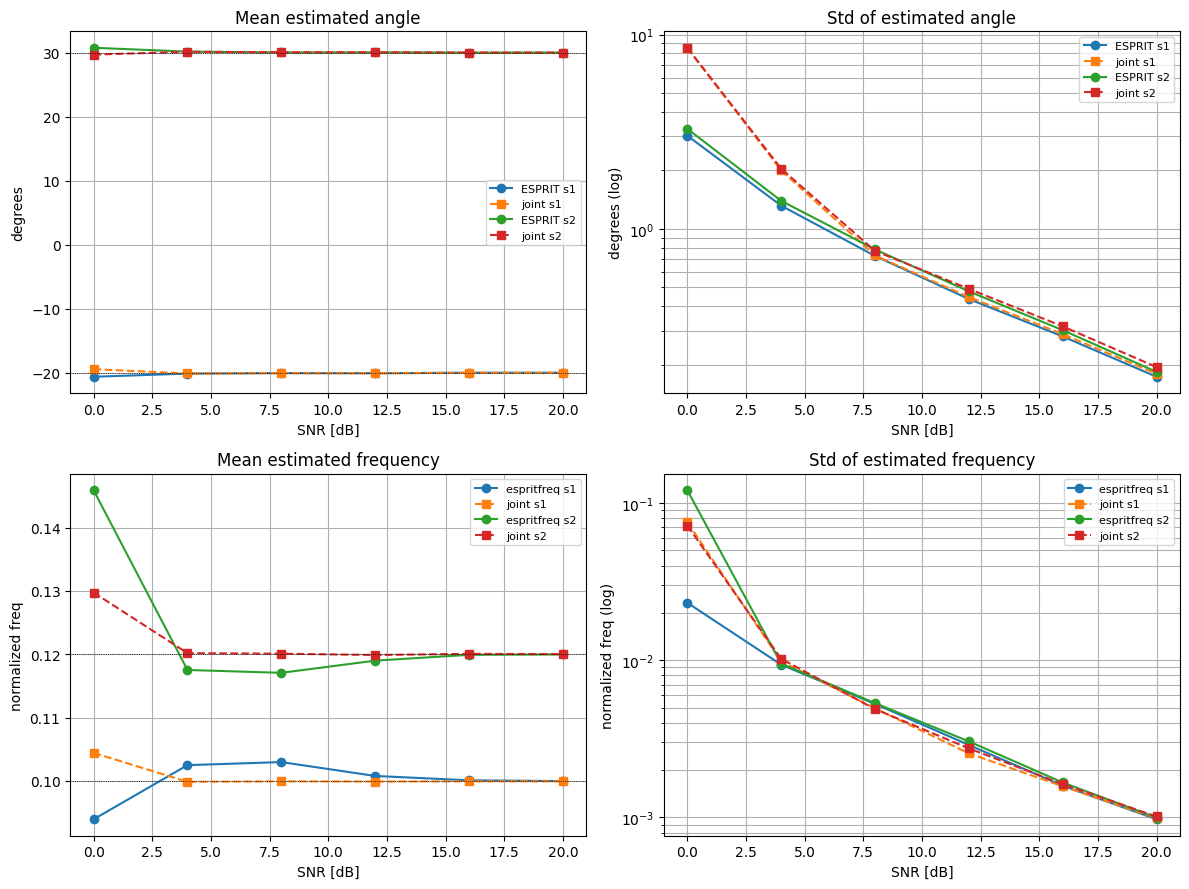

In [4]:
# Experiment parameters 
M_exp = 3
d = 2
f_exp = np.array([0.10, 0.12])
m_smooth = 2  # smoothing factor for joint()
SNR_dB = np.arange(0, 21, 4)  # 0, 4, ..., 20
n_runs = 1000

# angles
th_esprit = np.zeros((len(SNR_dB), n_runs, d))
th_joint  = np.zeros((len(SNR_dB), n_runs, d))

# frequencies
f_espfreq = np.zeros((len(SNR_dB), n_runs, d))
f_joint   = np.zeros((len(SNR_dB), n_runs, d))

# Monte Carlo 
rng = np.random.default_rng(0)             
for si, snr in enumerate(SNR_dB):
    for r in range(n_runs):
        X, A, S = utils.gendata(M, N, delta, theta, f_exp, snr)

        # ESPRIT angles
        th = utils.esprit(X, d)
        th_esprit[si, r] = utils.match(np.real(th), theta)

        # ESPRIT-freq 
        ff = utils.espritfreq(X, d)
        f_espfreq[si, r] = utils.match(np.real(ff), f_exp)

        # Joint 
        thj, fj = utils.joint(X, d, m_smooth)
        thj, fj = utils.match_joint(np.real(thj), np.real(fj), theta, f_exp)
        th_joint[si, r] = thj
        f_joint[si, r]  = fj


# Statistics over runs 
th_e_mean, th_e_std = utils.stats(th_esprit)
th_j_mean, th_j_std = utils.stats(th_joint)
f_f_mean,  f_f_std  = utils.stats(f_espfreq)
f_j_mean,  f_j_std  = utils.stats(f_joint)


# Plot: 2x2 (angle mean / angle std / freq mean / freq std) 
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# Angle means
for k in range(d):
    ax[0,0].plot(SNR_dB, th_e_mean[:,k], 'o-',  label=f'ESPRIT s{k+1}')
    ax[0,0].plot(SNR_dB, th_j_mean[:,k], 's--', label=f'joint s{k+1}')
for t in theta:
    ax[0,0].axhline(t, color='k', lw=0.6, ls=':')
ax[0,0].set_title('Mean estimated angle'); ax[0,0].set_ylabel('degrees')
ax[0,0].set_xlabel('SNR [dB]'); ax[0,0].legend(fontsize=8); ax[0,0].grid(True)

# Angle std
for k in range(d):
    ax[0,1].semilogy(SNR_dB, th_e_std[:,k], 'o-',  label=f'ESPRIT s{k+1}')
    ax[0,1].semilogy(SNR_dB, th_j_std[:,k], 's--', label=f'joint s{k+1}')
ax[0,1].set_title('Std of estimated angle'); ax[0,1].set_ylabel('degrees (log)')
ax[0,1].set_xlabel('SNR [dB]'); ax[0,1].legend(fontsize=8); ax[0,1].grid(True, which='both')

# Frequency means
for k in range(d):
    ax[1,0].plot(SNR_dB, f_f_mean[:,k], 'o-',  label=f'espritfreq s{k+1}')
    ax[1,0].plot(SNR_dB, f_j_mean[:,k], 's--', label=f'joint s{k+1}')
for fv in f_exp:
    ax[1,0].axhline(fv, color='k', lw=0.6, ls=':')
ax[1,0].set_title('Mean estimated frequency'); ax[1,0].set_ylabel('normalized freq')
ax[1,0].set_xlabel('SNR [dB]'); ax[1,0].legend(fontsize=8); ax[1,0].grid(True)

# Frequency std
for k in range(d):
    ax[1,1].semilogy(SNR_dB, f_f_std[:,k], 'o-',  label=f'espritfreq s{k+1}')
    ax[1,1].semilogy(SNR_dB, f_j_std[:,k], 's--', label=f'joint s{k+1}')
ax[1,1].set_title('Std of estimated frequency'); ax[1,1].set_ylabel('normalized freq (log)')
ax[1,1].set_xlabel('SNR [dB]'); ax[1,1].legend(fontsize=8); ax[1,1].grid(True, which='both')

plt.tight_layout()
plt.show()

### Creating two zero-forcing beamformers 

In [8]:
# Create near noiseless data
X, _, _ = utils.gendata(M, N, delta, theta, f, SNR=100)  

# Beamformer 1: Using angle information
theta_hat = utils.esprit(X, d)
A_hat = np.column_stack([utils.a(th, M, delta).flatten() for th in theta_hat])  # M x d
W_theta = np.linalg.pinv(A_hat)  # this is W^H directly (d x M)
S_theta = W_theta @ X # recovered sources, d x N

# Beamformer 2: Using frequency information
f_hat = utils.espritfreq(X, d)
S_hat = np.array([np.exp(1j*2*np.pi*fi*np.arange(N)) for fi in f_hat])  # d x N
W_f = S_hat @ np.linalg.pinv(X)  # d x M, this is W^H
S_freq = W_f @ X               


# Align the rows
S_theta_aligned = utils.match_rows(S, S_theta)
S_freq_aligned  = utils.match_rows(S, S_freq)

# Calculate MSE
mse_theta = np.mean(np.abs(S - S_theta_aligned)**2)
mse_freq  = np.mean(np.abs(S - S_freq_aligned)**2)

print(f"MSE angle-based (esprit)     : {mse_theta:.3e}")
print(f"MSE frequency-based (espritfreq): {mse_freq:.3e}")

MSE angle-based (esprit)     : 2.132e-01
MSE frequency-based (espritfreq): 2.132e-01


### Comparing the spatial responses of the beamformers

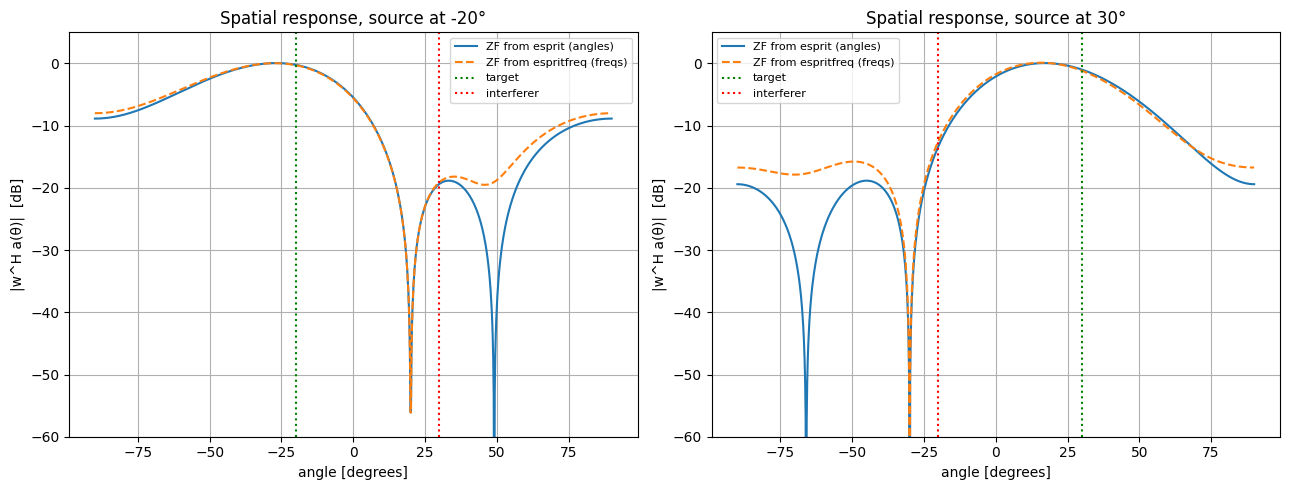

In [ ]:
# Parameters
M = 3
N = 20
d = 2
theta_true = [-20, 30]
f_true = [0.1, 0.12]
SNR = 10

# Generate noisy data 
X, A, S = utils.gendata(M, N, delta, theta_true, f_true, SNR)

# Rebuild BOTH beamformers here with M = 3
theta_hat = utils.esprit(X, d)
A_hat = np.column_stack([utils.a(th, M, delta).flatten() for th in theta_hat])
W_theta = np.linalg.pinv(A_hat)                     

f_hat = utils.espritfreq(X, d)
S_hat = np.array([np.exp(1j*2*np.pi*fi*np.arange(N)) for fi in f_hat])
W_f = S_hat @ np.linalg.pinv(X)  

# Reorder W_f rows so row i targets the same source as W_theta row i
order_theta = [utils.target_index(W_theta[i], theta_true, M, delta) for i in range(d)]
order_f = [utils.target_index(W_f[i], theta_true, M, delta) for i in range(d)]

# build a map so both index by true-source order
W_theta_sorted = np.zeros_like(W_theta)
W_f_sorted = np.zeros_like(W_f)
for i in range(d):
    W_theta_sorted[order_theta[i]] = W_theta[i]
    W_f_sorted[order_f[i]]         = W_f[i]

# Compute spatial responses y(theta) = |w^H a(theta)| 
angles = np.linspace(-90, 90, 1000)

# Plot one subplot per source 
fig, axes = plt.subplots(1, d, figsize=(13, 5))
for i in range(d):
    y_theta = utils.spatial_response(W_theta_sorted[i], M, delta, angles)
    y_freq  = utils.spatial_response(W_f_sorted[i], M, delta, angles)

    # Convert to dB
    y_theta_db = 20*np.log10(y_theta)
    y_freq_db  = 20*np.log10(y_freq)

    ax = axes[i]
    ax.plot(angles, y_theta_db, label='ZF from esprit (angles)')
    ax.plot(angles, y_freq_db,  label='ZF from espritfreq (freqs)', linestyle='--')
    # mark the true source angles
    ax.axvline(theta_true[i],  color='g', linestyle=':', label='target')
    ax.axvline(theta_true[1-i], color='r', linestyle=':', label='interferer')
    ax.set_title(f'Spatial response, source at {theta_true[i]}°')
    ax.set_xlabel('angle [degrees]')
    ax.set_ylabel('|w^H a(θ)|  [dB]')
    ax.set_ylim(-60, 5)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Channel Equalization